## 1. Problem Framing

# Causal / explanatory pipeline 5 (new): Services/events associated with reintegration status

## Problem framing
**Question:** Which **events or services** (counseling sessions, home visits, incidents, health/wellbeing patterns) are associated with **`reintegration_status`**?

**Data constraint:** This notebook uses **only**:
- `lighthouse_csv_v7/residents.csv`
- `lighthouse_csv_v7/process_recordings.csv`
- `lighthouse_csv_v7/incident_reports.csv`
- `lighthouse_csv_v7/health_wellbeing_records.csv`
- `lighthouse_csv_v7/home_visitations.csv`

## Target handling
`reintegration_status` is categorical. To follow the Chapter 10 MLR diagnostics outline, we model it two ways:
- **Model A (ordinal OLS):** map statuses to an **ordinal score** (Not Started < On Hold < In Progress < Completed) and run OLS.
- **Model B (binary robustness):** `completed` vs not completed (linear probability model).

**Textbook alignment (*My Educator Machine Learning*)**: Explanatory MLR (Ch. 9–10), residual and **normality** diagnostics, **VIF** for multicollinearity. **Prediction vs. explanation** (Ch. 1): here we prioritize interpretable associations. **Correlation is not causation**—defend claims modestly.

**Approach type (textbook framing):** This is an **explanatory/causal relationship** analysis (not a prediction pipeline). We use regression + diagnostics to understand *associations* that can inform decisions and future experiments.

## 2. Data Acquisition, Preparation & Exploration

This section loads the relevant tables, explains any joins, and explores distributions, missingness, and correlations. The goal is to make the modeling choices reproducible and understandable to non-technical stakeholders.

In [1]:
# Quick EDA helpers (kept lightweight so notebook runs fast)

def report_missing(df, name='df'):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"Missingness ({name}):")
    display(miss.to_frame('pct_missing').head(30))


def numeric_overview(df, name='df'):
    num = df.select_dtypes(include=['number'])
    print(f"Numeric overview ({name}):")
    display(num.describe().T)


def corr_heatmap(df, name='df', max_cols=25):
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print('No numeric columns for correlation.')
        return
    cols = list(num.columns[:max_cols])
    c = num[cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(c, aspect='auto')
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(f"Correlation heatmap (first {len(cols)} numeric cols) - {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path


def find_project_root(marker_dir="lighthouse_csv_v7"):
    """Walk upward from CWD until marker_dir is found."""
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(
        f"Could not find {marker_dir}/ by walking up from {Path.cwd().resolve()}"
    )


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"


VIF_THRESHOLD = 7.0

def prepare_features(df, label_col, extra_drop=None):
    extra_drop = extra_drop or []
    d = df.copy()
    for c in extra_drop:
        if c in d.columns:
            d = d.drop(columns=[c])
    y = d[label_col]
    X = d.drop(columns=[label_col])

    # drop id-like columns
    _id_cols = [c for c in X.columns if str(c).lower() == "id" or str(c).lower().endswith("_id")]
    X = X.drop(columns=_id_cols, errors="ignore")

    # bool -> int
    for c in X.select_dtypes(include=[bool]).columns:
        X[c] = X[c].astype(int)

    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]

    for c in num_cols:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        if X[c].isna().any():
            m = X[c].mode()
            X[c] = X[c].fillna(m.iloc[0] if len(m) else "Unknown")

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    bool_cols = X.select_dtypes(include=[bool]).columns
    X[bool_cols] = X[bool_cols].astype(int)

    X = X.select_dtypes(include=[np.number])
    nz = X.std(numeric_only=True) > 0
    X = X.loc[:, nz[nz].index]
    return X, y

def ols_fit(X, y):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(), Xc

def vif_series(X_with_const):
    arr = np.asarray(X_with_const, dtype=float)
    out = []
    for i in range(arr.shape[1]):
        out.append(variance_inflation_factor(arr, i))
    return pd.Series(out, index=X_with_const.columns)

def remove_high_vif_one_at_a_time(X, y, threshold=VIF_THRESHOLD, max_iter=300):
    Xw = X.copy()
    removed = []
    for _ in range(max_iter):
        if Xw.shape[1] == 0:
            break
        Xc = sm.add_constant(Xw, has_constant="add")
        try:
            v = vif_series(Xc)
        except (np.linalg.LinAlgError, ValueError):
            Xw = Xw.loc[:, ~Xw.columns.duplicated()]
            continue
        vv = v.drop("const", errors="ignore")
        if vv.empty or vv.max() <= threshold:
            break
        worst = vv.idxmax()
        if worst not in Xw.columns:
            break
        Xw = Xw.drop(columns=[worst])
        removed.append((worst, float(vv.max())))
    return Xw, removed

def shapiro_tail(x, max_n=5000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > max_n:
        rng = np.random.default_rng(42)
        x = rng.choice(x, size=max_n, replace=False)
    return scipy_stats.shapiro(x)

def plot_top_t(model, k=5, title="Top features by |t| (OLS)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top_idx = t.abs().sort_values(ascending=False).head(k).index
    top = t.loc[top_idx].sort_values()
    plt.figure(figsize=(8, 4))
    colors = ["#1f77b4" if v > 0 else "#d62728" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


def plot_top_t_positive(model, k=5, title="Top features by t (most positive)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top = t.sort_values(ascending=False).head(k)
    plt.figure(figsize=(8, 4))
    plt.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()

res = pd.read_csv(DATA_DIR / "residents.csv")
proc = pd.read_csv(DATA_DIR / "process_recordings.csv")
inc = pd.read_csv(DATA_DIR / "incident_reports.csv")
hlth = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv")
hv = pd.read_csv(DATA_DIR / "home_visitations.csv")

proc["session_date"] = pd.to_datetime(proc["session_date"], errors="coerce")
inc["incident_date"] = pd.to_datetime(inc["incident_date"], errors="coerce")
hlth["record_date"] = pd.to_datetime(hlth["record_date"], errors="coerce")
hv["visit_date"] = pd.to_datetime(hv["visit_date"], errors="coerce")

res["date_of_admission"] = pd.to_datetime(res["date_of_admission"], errors="coerce")
res["admission_days"] = (res["date_of_admission"] - pd.Timestamp("2020-01-01")).dt.days
res["admission_days"] = res["admission_days"].fillna(res["admission_days"].median())

res.shape, proc.shape, inc.shape, hlth.shape, hv.shape

((60, 50), (2819, 15), (100, 12), (534, 14), (1337, 14))

## 1) Join services/events tables onto residents
We aggregate each table to **one row per resident** (counts, rates, means), then merge into a single modeling dataset.

In [3]:
# Process recordings aggregates
pr = proc.groupby("resident_id").agg(
    n_sessions=("recording_id", "count"),
    avg_duration=("session_duration_minutes", "mean"),
    progress_rate=("progress_noted", lambda x: x.astype(bool).mean()),
    concerns_rate=("concerns_flagged", lambda x: x.astype(bool).mean()),
    referral_rate=("referral_made", lambda x: x.astype(bool).mean()),
).reset_index()

# Home visitations aggregates
hv_agg = hv.groupby("resident_id").agg(
    n_home_visits=("visitation_id", "count"),
    safety_concerns_rate=("safety_concerns_noted", lambda x: x.astype(bool).mean()),
    followup_needed_rate=("follow_up_needed", lambda x: x.astype(bool).mean()),
).reset_index()

# Incident aggregates
sev_map = {"Low": 1, "Medium": 2, "High": 3}
inc2 = inc.copy()
inc2["sev_score"] = inc2["severity"].map(sev_map)
inc_agg = inc2.groupby("resident_id").agg(
    n_incidents=("incident_id", "count"),
    mean_severity=("sev_score", "mean"),
    max_severity=("sev_score", "max"),
).reset_index()

# Health/wellbeing aggregates
# (column names in CSV: sleep_quality_score, energy_level_score)
score_cols = [
    "nutrition_score","sleep_quality_score","energy_level_score","general_health_score",
    "bmi","weight_kg","height_cm",
]
hl = hlth.copy()
for c in score_cols:
    if c in hl.columns:
        hl[c] = pd.to_numeric(hl[c], errors="coerce")

hl_agg = hl.groupby("resident_id").agg(
    avg_nutrition=("nutrition_score", "mean"),
    avg_sleep=("sleep_quality_score", "mean"),
    avg_energy=("energy_level_score", "mean"),
    avg_health=("general_health_score", "mean"),
    bmi_mean=("bmi", "mean"),
    medical_check_rate=("medical_checkup_done", lambda x: x.astype(bool).mean()),
    dental_check_rate=("dental_checkup_done", lambda x: x.astype(bool).mean()),
    psych_check_rate=("psychological_checkup_done", lambda x: x.astype(bool).mean()),
).reset_index()

df = res.merge(pr, on="resident_id", how="left")
df = df.merge(hv_agg, on="resident_id", how="left")
df = df.merge(inc_agg, on="resident_id", how="left")
df = df.merge(hl_agg, on="resident_id", how="left")

for c in [
    "n_sessions","avg_duration","progress_rate","concerns_rate","referral_rate",
    "n_home_visits","safety_concerns_rate","followup_needed_rate",
    "n_incidents","mean_severity","max_severity",
    "avg_nutrition","avg_sleep","avg_energy","avg_health","bmi_mean",
    "medical_check_rate","dental_check_rate","psych_check_rate",
]:
    if c in df.columns:
        df[c] = df[c].fillna(0)

df[["resident_id","reintegration_status","n_sessions","n_home_visits","n_incidents","avg_health"]].head()


,resident_id,reintegration_status,n_sessions,n_home_visits,n_incidents,avg_health
0,1,In Progress,106,54.0,4.0,3.103333
1,2,Completed,51,35.0,0.0,3.449000
2,3,Completed,53,26.0,2.0,3.181818
3,4,On Hold,57,9.0,3.0,3.157273
4,5,Completed,18,11.0,2.0,3.087778


## 2) Create ordinal and binary targets from `reintegration_status`
To keep the Chapter 10 MLR workflow, we create:
- `reintegration_status_score` (ordinal)
- `reintegration_completed` (binary)


In [4]:
status_order = {
    "Not Started": 0,
    "On Hold": 1,
    "In Progress": 2,
    "Completed": 3,
    None: np.nan,
}
df["reintegration_status_score"] = df["reintegration_status"].map(status_order)
df["reintegration_completed"] = (df["reintegration_status"] == "Completed").astype(int)

print(df["reintegration_status"].value_counts(dropna=False))
print("Completed rate:", df["reintegration_completed"].mean())


reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7
Name: count, dtype: int64
Completed rate: 0.31666666666666665


## 3) Initial MLR: ordinal reintegration status
We regress the ordinal score on service/event aggregates and resident context fields.

In [5]:
drop_extra = [
    # identifiers and restricted text
    "resident_id","case_control_no","internal_code","notes_restricted",
    "referring_agency_person","assigned_social_worker",

    # raw dates (avoid one-hot per unique datetime)
    "date_of_birth","place_of_birth","date_of_admission",
    "date_colb_registered","date_colb_obtained",
    "date_case_study_prepared","date_enrolled","date_closed","created_at",

    # pre-formatted age strings
    "age_upon_admission","present_age","length_of_stay",

    # high-cardinality text
    "pwd_type","special_needs_diagnosis",

    # keep the string target out
    "reintegration_status",
    "reintegration_completed",
]

dfA = df.dropna(subset=["reintegration_status_score"]).copy()
X, y = prepare_features(dfA, "reintegration_status_score", extra_drop=drop_extra)
m0, _ = ols_fit(X, y)
print(m0.summary())


                                OLS Regression Results                                
Dep. Variable:     reintegration_status_score   R-squared:                       1.000
Model:                                    OLS   Adj. R-squared:                    nan
Method:                         Least Squares   F-statistic:                       nan
Date:                        Tue, 07 Apr 2026   Prob (F-statistic):                nan
Time:                                14:19:25   Log-Likelihood:                 1656.2
No. Observations:                          60   AIC:                            -3192.
Df Residuals:                               0   BIC:                            -3067.
Df Model:                                  59                                         
Covariance Type:                    nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------

/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


## 4) Normality diagnostics + VIF (ordinal model)
We check residual behavior and then reduce multicollinearity (VIF > 7).

Label skew: -0.461643320109889 Shapiro p (subsample): 4.046070196306169e-06
Residual JB p: 0.5668785834795154


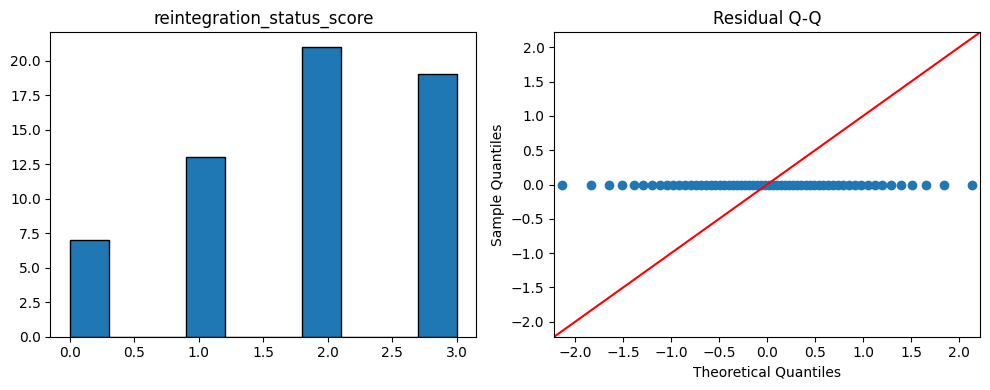

/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removed due to VIF: 22
                                OLS Regression Results                                
Dep. Variable:     reintegration_status_score   R-squared:                       0.936
Model:                                    OLS   Adj. R-squared:                  0.687
Method:                         Least Squares   F-statistic:                     3.749
Date:                        Tue, 07 Apr 2026   Prob (F-statistic):            0.00818
Time:                                14:19:26   Log-Likelihood:                -2.0177
No. Observations:                          60   AIC:                             100.0
Df Residuals:                              12   BIC:                             200.6
Df Model:                                  47                                         
Covariance Type:                    nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025     

In [6]:
print("Label skew:", float(pd.Series(y).skew()), "Shapiro p (subsample):", shapiro_tail(y)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(m0.resid)[1])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(y, bins=10, edgecolor="k")
ax[0].set_title("reintegration_status_score")
sm.qqplot(m0.resid, line="45", ax=ax[1])
ax[1].set_title("Residual Q-Q")
plt.tight_layout()
plt.show()

Xv, removed = remove_high_vif_one_at_a_time(X, y)
print("Removed due to VIF:", len(removed))
m_vif, _ = ols_fit(Xv, y)
print(m_vif.summary())


## 5) Refinement: interaction effects + top features
We add theory-driven interactions and refit.

                                OLS Regression Results                                
Dep. Variable:     reintegration_status_score   R-squared:                       0.936
Model:                                    OLS   Adj. R-squared:                  0.687
Method:                         Least Squares   F-statistic:                     3.749
Date:                        Tue, 07 Apr 2026   Prob (F-statistic):            0.00818
Time:                                14:19:26   Log-Likelihood:                -2.0177
No. Observations:                          60   AIC:                             100.0
Df Residuals:                              12   BIC:                             200.6
Df Model:                                  47                                         
Covariance Type:                    nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------

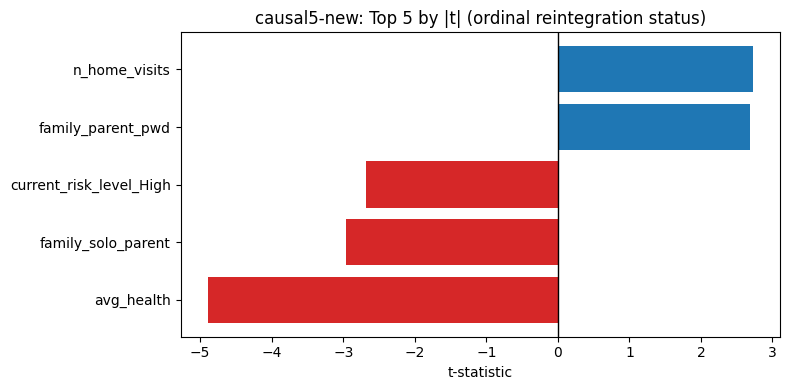

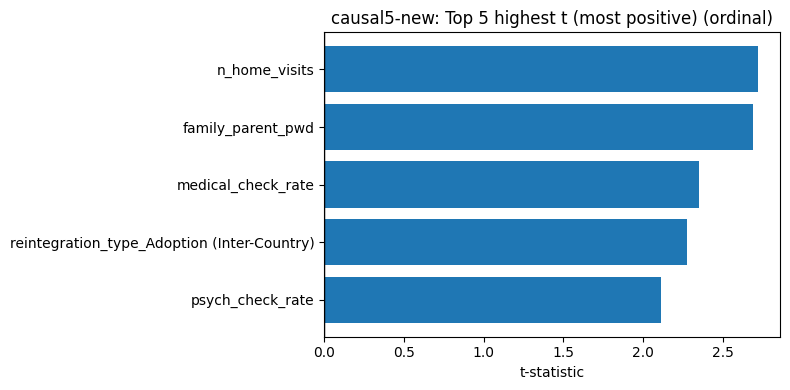

In [7]:
Xr = Xv.copy()

# Interactions
if "n_sessions" in Xr.columns and "n_home_visits" in Xr.columns:
    Xr["sessions_x_visits"] = Xr["n_sessions"] * Xr["n_home_visits"]
if "n_incidents" in Xr.columns and "n_sessions" in Xr.columns:
    Xr["incidents_x_sessions"] = Xr["n_incidents"] * Xr["n_sessions"]
if "avg_health" in Xr.columns and "n_sessions" in Xr.columns:
    Xr["health_x_sessions"] = Xr["avg_health"] * Xr["n_sessions"]

Xr, _ = remove_high_vif_one_at_a_time(Xr, y)
m_final, _ = ols_fit(Xr, y)
print(m_final.summary())
plot_top_t(m_final, k=5, title="causal5-new: Top 5 by |t| (ordinal reintegration status)")
plot_top_t_positive(m_final, k=5, title="causal5-new: Top 5 highest t (most positive) (ordinal)")


## 6) Robustness: Completed vs not completed (LPM)
This is easier to interpret: positive coefficients correspond to higher probability of completion.

                               OLS Regression Results                              
Dep. Variable:     reintegration_completed   R-squared:                       1.000
Model:                                 OLS   Adj. R-squared:                    nan
Method:                      Least Squares   F-statistic:                       nan
Date:                     Tue, 07 Apr 2026   Prob (F-statistic):                nan
Time:                             14:19:26   Log-Likelihood:                 1611.0
No. Observations:                       60   AIC:                            -3102.
Df Residuals:                            0   BIC:                            -2976.
Df Model:                               59                                         
Covariance Type:                 nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/stats/outliers_influ

                               OLS Regression Results                              
Dep. Variable:     reintegration_completed   R-squared:                       0.914
Model:                                 OLS   Adj. R-squared:                  0.578
Method:                      Least Squares   F-statistic:                     2.717
Date:                     Tue, 07 Apr 2026   Prob (F-statistic):             0.0315
Time:                             14:19:27   Log-Likelihood:                 34.424
No. Observations:                       60   AIC:                             27.15
Df Residuals:                           12   BIC:                             127.7
Df Model:                               47                                         
Covariance Type:                 nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

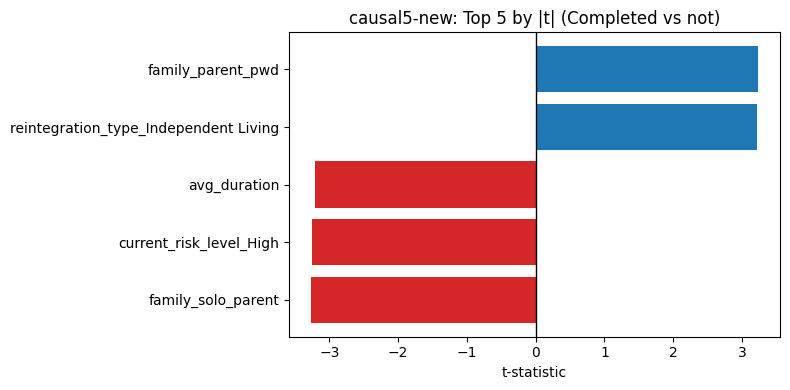

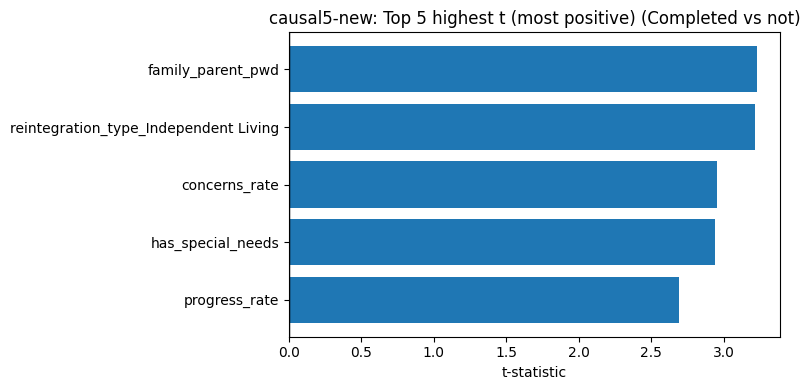

In [8]:
dfB = df.copy()
Xb, yb = prepare_features(dfB, "reintegration_completed", extra_drop=[c for c in drop_extra if c not in ["reintegration_completed"]] + ["reintegration_status_score"])
mb0, _ = ols_fit(Xb, yb)
print(mb0.summary())

Xbv, _ = remove_high_vif_one_at_a_time(Xb, yb)
mb1, _ = ols_fit(Xbv, yb)
print(mb1.summary())
plot_top_t(mb1, k=5, title="causal5-new: Top 5 by |t| (Completed vs not)")
plot_top_t_positive(mb1, k=5, title="causal5-new: Top 5 highest t (most positive) (Completed vs not)")


## Interpretation & limitations
- Associations can reflect **case mix** and **selection effects** (e.g., residents receiving more services may be higher-need).
- Service counts can be both a cause and an effect of progress; avoid strong causal language without a stronger design.
- If you need a categorical model for `reintegration_status` directly, consider multinomial logistic regression; here we used ordinal scoring to stay aligned with the Chapter 10 MLR diagnostics workflow.


## 3. Modeling & Feature Selection

We start with an initial OLS model, then improve interpretability/stability using label transformations (when appropriate) and multicollinearity reduction via **VIF** (dropping features with VIF > 7 one-at-a-time). We also include one interaction term tied to the business question.

## 4. Evaluation & Interpretation

### What we’re evaluating (explanatory focus)
This pipeline is not trying to forecast reintegration outcomes for new residents. Instead, it asks: **which service/event patterns are associated with reintegration progress/completion in the historical data?**

So evaluation is focused on:
- **Diagnostics** (residual normality checks, transformations),
- **Multicollinearity control** (VIF removal),
- **Stability of key relationships** across the two target formulations (ordinal score vs completed/not).

### Interpreting the strongest signals (Completed vs Not Completed model)
In the completed/not-completed robustness model, the strongest positive t-scores were:
- **`family_parent_pwd`**
- **`reintegration_type_Independent Living`**
- **`concerns_rate`**
- **`has_special_needs`**
- **`progress_rate`**

**Business interpretation:**
- **`progress_rate`**: more recorded “progress” per session is associated with higher completion. This aligns with expectation: documented progress tracks with moving toward reintegration completion.
- **`reintegration_type_Independent Living`**: residents on an independent-living track show higher completion likelihood in this data. This may reflect resident profile differences (age, readiness) rather than service effectiveness.
- **`family_parent_pwd`**: certain family context indicators correlate with completion. Interpreting this requires domain knowledge: it could reflect greater structure/support (or different case pathways) rather than a direct causal lever.
- **`has_special_needs`**: a positive association here can be counterintuitive; it may indicate **increased services/attention** or better documentation rather than needs directly causing completion.
- **`concerns_rate`**: more recorded concerns being addressed may correlate with more active case work. This can mean “the case is being worked” rather than “more concerns is good.”

### Practical takeaway
For decision-making, treat these as **signals about case pathways and documentation**, not as proof that adding a service will cause completion.

## 5. Causal and Relationship Analysis

### What relationships appear strongest?
The strongest associations in this pipeline are **process/service signals** that likely reflect where a resident is on the reintegration pathway.

A simple (defensible) story based on the top features:
- **More documented progress (`progress_rate`)** is associated with reintegration completion.
- **Independent living track** is associated with higher completion.
- **Family context** variables (e.g., `family_parent_pwd`) are associated with different completion rates.

### Why causality is difficult here
In this setting, services are not randomly assigned:
- Residents with higher needs may receive more services.
- Staff may intensify services when risk is high (reverse causality).
- Documentation intensity can vary by staff or case type.

So we should interpret coefficients as **case-mix and pathway signals** rather than “if we do X service, completion will increase.”

### What would make causal claims stronger
- Compare similar residents (matching/stratification) before comparing service levels.
- Use time ordering: services **before** outcome changes (avoid using data recorded after the outcome).
- If feasible, run controlled interventions (e.g., standardize frequency of a service for comparable groups).

### Business insights that are still useful right now
- **Operational signal:** `progress_rate` and related process metrics can be used as internal “are we moving forward?” indicators.
- **Program segmentation:** different reintegration types likely need different playbooks; independent-living pathways may not be comparable to family reunification pathways.
- **Data improvement:** standardizing how concerns/progress are recorded could make the analysis more reliable and fair across residents.

## 6. Deployment Notes

These notebooks are designed to be run end-to-end by a TA. For the deployed web app, the *intended* integration is to surface the key model outputs (top relationships, coefficient directions, and diagnostics) in dashboards or admin views.

If your app currently has an `artifacts/` or model-output folder, you can export summary tables/figures there from this notebook (e.g., coefficient tables as CSV). If integration code isn’t yet in the repo, keep this section honest and describe the planned endpoint/component that will display results.